# Connaissance et pratique de la Science Ouverte

In [1]:
import pandas as pd

import os #pour naviguer dans les dossiers
from io import StringIO
import s3fs #pour connecter au bucket
import scipy.stats

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:


# Create filesystem object
S3_ENDPOINT_URL = "https://" + os.environ["AWS_S3_ENDPOINT"]
fs = s3fs.S3FileSystem(client_kwargs={'endpoint_url': S3_ENDPOINT_URL})

BUCKET_OUT = "aluneau"



In [3]:
with fs.open(f"{BUCKET_OUT}/data_eP8/raw/anonymous_answer_2026-07-24.csv", "r") as file_in:
    df0 = pd.read_csv(file_in, sep =",")

list_affil = pd.read_csv("list_affiliation.csv", sep =",")
df0 = df0.loc[~df0.q45_clé.isin(["9EAP-NB4B","QNYZ-3MH2"])].merge(list_affil, on = ["q45_clé", "q44_ufr_labo"], how = "left")

In [65]:

df_col = pd.read_csv("../le_questionnaire/dico_variable.csv", sep = ",")


In [14]:
list_nominal_simple = [x for x in df_col.label.loc[(df_col.type.isin(["simple_nominal", "booléen","ordinal"]))]]


In [9]:
def split_multiple_choices(data, column, index, sep = '|'):
    """
    split and explode column with multiple value

    data = a panda dataframe
    column = name of column which we want to split.
    index = column corresponding to id of rows
    sep = by default '|'. Character use to separate values.
    """
    df_split = data.copy()
    df_split[column]= df_split.apply(lambda row: row[column].replace(";","|") ,1 )
    df_split[column] = df_split[column].str.split(sep)
    df_explode = df_split.explode(column)
    gb_data = df_explode.groupby([column]).agg(nb = (index, "size")).sort_values("nb", ascending=False).reset_index()
    gb_data["total"] = data[index].nunique()
    gb_data["freq"] = gb_data.nb/gb_data.total*100
    gb_data["total_freq"] = gb_data.total/gb_data.total*100
    
    return df_explode, gb_data
    

In [10]:
def grouped_question(data, column, index = "q45_clé"):
    """


    data = a panda dataframe
    column = name of column which we want to split.
    index = column corresponding to id of rows
    sep = by default '|'. Character use to separate values.
    """
    df_tmp = data.copy()
    gb_data = df_tmp.groupby([column]).agg(nb = (index, "size")).reset_index()
    gb_data["total"] = data[index].nunique()
    gb_data["freq"] = gb_data.nb/gb_data.total*100
    gb_data["total_freq"] = gb_data.total/gb_data.total*100

    return gb_data

In [11]:
df0

,qno_obs,q1_so_principles,q2_hal_depot,q3_octavi_depot,q4_diff_data,q4_autres_entrepots,q5_r,q5_python,q5_excel,q5_julia,...,q54_appareil_utilisé_pour_la_saisie,q25_statut_rec,q25_doctorant,q3_octavi_rec,q4_autres_entrepots_rec,q5_logiciel_traitement_rec,q5_1_other_lang_rec,q5_family_logi,q4_diff_data_grouped,q4_diff_data_rec
0,1,"Oui, un peu","Oui, une fois",Non,Non,NaN,Non,Non,Non,Non,...,PC,Doctorant,True,Non,NaN,NaN,NaN,NaN,Non,Non
1,2,"Oui, un peu","Oui, une fois",Non,Non,NaN,Non,Non,Non,Non,...,PC,Chercheur,False,Non,NaN,NaN,NaN,NaN,Non,Non
2,3,"Oui, tout à fait","Oui, plusieurs fois",Je ne connais pas Octaviana,Non,NaN,Non,Non,Oui,Non,...,PC,Chercheur,False,Non,NaN,excel|maxqda|endnotes|zotero,maxqda|endnotes|zotero,feuille de calcul|CAQDAS|gestion biblio,Non,Non
3,4,"Oui, un peu","Oui, une fois",Non,"Autre, précisez",OSF,Oui,Non,Non,Non,...,PC,Chercheur,False,Non,osf,r,NaN,script et programmation,Oui,osf
4,6,"Oui, un peu","Oui, systématiquement",Non;Je ne connais pas Octaviana,Non,NaN,Oui,Non,Oui,Non,...,PC,Chercheur,False,Non,NaN,r|excel,aucun,script et programmation|feuille de calcul,Non,Non
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,117,"Oui, un peu","Oui, plusieurs fois",Non,"Autre, précisez",OSF,Oui,Oui,Oui,Non,...,PC,Doctorant,True,Non,osf,r|python|excel,NaN,script et programmation|feuille de calcul,Oui,osf
115,118,"Oui, un peu","Oui, systématiquement",Non,Non,NaN,Oui,Non,Oui,Non,...,PC,Chercheur,False,Non,NaN,r|excel,NaN,script et programmation|feuille de calcul,Non,Non
116,119,"Oui, un peu","Oui, plusieurs fois",Non,Non,NaN,Oui,Non,Oui,Non,...,PC,Chercheur,False,Non,NaN,r|excel,NaN,script et programmation|feuille de calcul,Non,Non
117,120,Non,"Oui, plusieurs fois",Non;Je ne connais pas Octaviana,"Autre, précisez",Mendeley data,Non,Oui,Oui,Non,...,PC,Chercheur,False,Non,mendeley data,python|excel,NaN,script et programmation|feuille de calcul,Oui,mendeley data


In [12]:
df_col["question_family"] = df_col.label.apply(lambda row : row.split("_")[0])

dict_question = dict(zip(df_col.label.loc[df_col.label.isin(list_nominal_simple)], df_col.question_family.loc[df_col.label.isin(list_nominal_simple)]))


NameError: name 'list_nominal_simple' is not defined

Les premières questions interrogeaient les participants sur leurs connaissances et leurs pratiques de la Science Ouverte, thème central de l'enquête. Le questionnaire commencait ainsi par demander aux participants de préciser leur degré de familiarité avec les principes de la Science Ouverte. 56% ont répond "oui, un peu", 32 "oui, tout à fait" et 12% "non". Les pratiques étaient ensuite abordaient à travers des questions sur le dépôt des publications sur Hal et Octaviana, et l'ouverture de données de recherche.

40 % des personnes interrogées ont déposé plusieurs fois leurs publications sur Hal et 35% le font systématiquement. 13%  ne l'ont jamais fais. Concernant Octaviana, un peu moins de 10% des répondants ont déjà déposé des productions sur la bibliothèque numérique. Ces productions sont des captations d'événements pour trois d'entre elles et des travaux universitaires et des publications pour les huit autres. En tout une personne interrogée sur cinq n'a jamais entendu parlé d'Octaviana.

| Principes de la science ouverte   |   nb |    freq |
|:-------------------|-----:|--------:|
| Non                |   14 | 11,8 |
| Oui, tout à fait   |   38 | 31,9 |
| Oui, un peu        |   67 | 56,3 |
|Total               |119   | 100,0|


|Dépôt dans Hal        |   nb |    freq |
|:----------------------|-----:|--------:|
| Non                   |   15 | 12,6  |
| Oui, plusieurs fois   |   48 | 40,3 |
| Oui, systématiquement |   41 | 34,5 |
| Oui, une fois         |   15 | 12,6 |
|Total               |119   | 100,0|


| Dépot sur Octaviana  |   nb |    freq |
|:----------------|-----:|--------:|
| Non             |  108 | 90,8 |
| Oui             |   11 |  9,2|
|Total               |119   | 100,0|

| Ouverture des données   |   nb |   total |      freq |  
|:------------------------|-----:|--------:|----------:|
| Non                     |   86 |     119 | 72,3  |      
| Autre, précisez         |   24 |     119 | 20,7   |          
| Oui, sur Nakala         |    5 |     119 |  4,2  |          
| Oui, sur Zenodo |    4 |     119 |  3,4  |         
| Oui, sur Data Paris 8   |    1 |     119 |  0,8 |        
  


Enfin, 28% des personnes interrogées ont déjà produit des données ouvertes. 8% d'entre elles ont utilisé au moins une fois des entrepôts généralistes comme Nakala (N=5), Zenodo (N=4) ou Data Paris 8 (N=1). Les autres modalité d'ouverture des données sont Open Science Framework (N=10), des sites web personnels (N=6), des dépôts "git" (N=3) et des entrepots spécialisés (N=3) liés à la linguistiques : Ortolang et Cocoon.

![](viz/autre_entrepot_rec.png)



In [13]:
!pip install tabulate

In [14]:
so_principe = grouped_question(df0, column="q1_so_principles", index = "q45_clé")
print(so_principe[["q1_so_principles", "nb","freq"]].to_markdown(index=False))
depot_hal = grouped_question(df0, column="q2_hal_depot", index = "q45_clé")
print("\n### Dépôt dans hal\n", depot_hal[["q2_hal_depot", "nb","freq"]].to_markdown(index=False))
octaviana = grouped_question(df0, column="q3_octavi_rec", index = "q45_clé")
print("\n### Dépôt dans Octaviana\n", octaviana[["q3_octavi_rec", "nb","freq"]].to_markdown(index=False))

df_exp, octaviana2 = split_multiple_choices(df0, column="q3_octavi_depot", index="q45_clé", sep = '|')
print("\n### Dépôt dans Octaviana détaillé \n", octaviana2.to_markdown())



| q1_so_principles   |   nb |    freq |
|:-------------------|-----:|--------:|
| Non                |   14 | 11.7647 |
| Oui, tout à fait   |   38 | 31.9328 |
| Oui, un peu        |   67 | 56.3025 |

### Dépôt dans hal
 | q2_hal_depot          |   nb |    freq |
|:----------------------|-----:|--------:|
| Non                   |   15 | 12.605  |
| Oui, plusieurs fois   |   48 | 40.3361 |
| Oui, systématiquement |   41 | 34.4538 |
| Oui, une fois         |   15 | 12.605  |

### Dépôt dans Octaviana
 | q3_octavi_rec   |   nb |    freq |
|:----------------|-----:|--------:|
| Non             |  108 | 90.7563 |
| Oui             |   11 |  9.2437 |



### Dépôt dans Octaviana détaillé 
 |    | q3_octavi_depot                                         |   nb |   total |     freq |   total_freq |
|---:|:--------------------------------------------------------|-----:|--------:|---------:|-------------:|
|  0 | Non                                                     |   93 |     119 | 78.1513  |          100 |
|  1 | Je ne connais pas Octaviana                             |   25 |     119 | 21.0084  |          100 |
|  2 | Des travaux universitaires                              |    5 |     119 |  4.20168 |          100 |
|  3 | Des publications                                        |    5 |     119 |  4.20168 |          100 |
|  4 | Des captations d'évènements (colloque, journée d'étude) |    3 |     119 |  2.52101 |          100 |


In [15]:
df0.loc[df0.q4_diff_data !="Non", "q4_diff_data_grouped"] = "Oui"
df0.loc[df0.q4_diff_data =="Non", "q4_diff_data_grouped"] = "Non"

depot_donnee = grouped_question(df0, column="q4_diff_data_grouped", index = "q45_clé")
print("\n### Dépôt des données de recherche\n", depot_donnee)

df_exp, depot_donnee2 = split_multiple_choices(df0, column="q4_diff_data", index="q45_clé", sep = '|')
print("\n### Dépôt dans Octaviana détaillé \n", depot_donnee2.to_markdown(index=False))


### Dépôt des données de recherche
   q4_diff_data_grouped  nb  total       freq  total_freq
0                  Non  85    119  71.428571       100.0
1                  Oui  34    119  28.571429       100.0

### Dépôt dans Octaviana détaillé 
 | q4_diff_data            |   nb |   total |      freq |   total_freq |
|:------------------------|-----:|--------:|----------:|-------------:|
| Non                     |   86 |     119 | 72.2689   |          100 |
| Autre, précisez         |   24 |     119 | 20.1681   |          100 |
| Oui, sur Nakala         |    5 |     119 |  4.20168  |          100 |
| Oui, sur Zenodo, Nakala |    4 |     119 |  3.36134  |          100 |
| Oui, sur Data Paris 8   |    1 |     119 |  0.840336 |          100 |


## Les autres modes de dépôt des données de recherche

In [16]:
df0.loc[df0["q4_diff_data"]=='Autre, précisez', "q4_diff_data_rec"] = df0.q4_autres_entrepots_rec
df0.loc[df0["q4_diff_data"]!='Autre, précisez', "q4_diff_data_rec"] = df0.q4_diff_data
df0.loc[df0["q4_diff_data_rec"].isna(), "q4_diff_data_rec"] = "NSP"
q4 = split_multiple_choices(df0, column="q4_diff_data_rec", index="q45_clé", sep = '|')

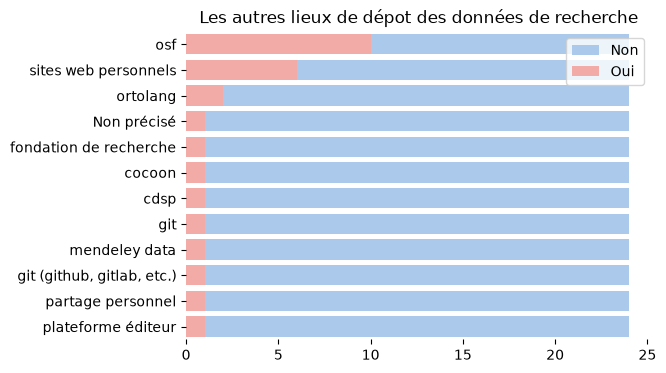

In [17]:
# Initialize the matplotlib figure
fig, ax = plt.subplots(1, figsize=(6,4))

# Plot the total crashes
sns.set_color_codes("pastel")
q4_other = df0.loc[df0.q4_diff_data=="Autre, précisez"].fillna("Non précisé")
col= "q4_autres_entrepots_rec"
df_exp, gb_data = split_multiple_choices(q4_other, column=col, index="q45_clé", sep = '|')
sns.barplot(x="total", y=col, data=gb_data,
            label="Non", color="b", ax=ax)
sns.barplot(x="nb", y=col, data=gb_data,
            label="Oui", color="r", ax=ax)
titre = "Les autres lieux de dépot des données de recherche"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))
    

sns.despine(left=True, bottom=True)
plt.savefig(f"viz/autre_entrepot_rec.png", bbox_inches='tight', dpi = 200)



## Les besoins d'accompagnement à la Science Ouverte

Mis à part l'accompagnement au dépot dans Hal considéré comme inutile par 68% des répondants, une majorité d'entre eux sont favorables aux accompagnement à la Science Ouverte comme étant utiles. Les licences de diffusion des résultats de recherche est le sujet pour lequel les répondants ont manifesté le plus d'intérêt : 87% considèrent qu'un accompagnement sur ce thème serait "plutôt utile" (52%) voire "très utile" (35%). Ensuite, 81% des participants à l'enquêtre déclarent qu'il serait utile d'être accompagner dans le processus permettant de produire des données respectant les principes FAIR (Facile à trouver, Accessible, Interopérable, et Réutilisable). De façon général, les accompagnements apparaissent d'autant plus utiles qu'ils portent sur des aspects juridiques (licence, RGPD) ou des sujets liés à l'ouverture des données (métadonnées, dépots, principes FAIR).

![](viz/util_accomp_so.png)


In [18]:
for col in df_col.label.loc[(df_col.group=="6_help_SO")&(df_col.type=="ordinal")]:
    gb_data= grouped_question(df0, column=col, index="q45_clé")
    print(gb_data.to_markdown())

|    | q8_depot_hal_help   |   nb |   total |    freq |   total_freq |
|---:|:--------------------|-----:|--------:|--------:|-------------:|
|  0 | Non, pas utile      |   81 |     119 | 68.0672 |          100 |
|  1 | Oui, plutôt utile   |   27 |     119 | 22.6891 |          100 |
|  2 | Oui, très utile     |   11 |     119 |  9.2437 |          100 |
|    | q8_rediger_pdg_help   |   nb |   total |    freq |   total_freq |
|---:|:----------------------|-----:|--------:|--------:|-------------:|
|  0 | Non, pas utile        |   44 |     119 | 36.9748 |          100 |
|  1 | Oui, plutôt utile     |   47 |     119 | 39.4958 |          100 |
|  2 | Oui, très utile       |   28 |     119 | 23.5294 |          100 |
|    | q8_respect_rgpd_help   |   nb |   total |    freq |   total_freq |
|---:|:-----------------------|-----:|--------:|--------:|-------------:|
|  0 | Non, pas utile         |   41 |     119 | 34.4538 |          100 |
|  1 | Oui, plutôt utile      |   50 |     119 | 42.0168 |

In [19]:
[col for col in df_col.label.loc[(df_col.group=="6_help_SO")&(df_col.type=="ordinal")]]

['q8_depot_hal_help',
 'q8_rediger_pdg_help',
 'q8_respect_rgpd_help',
 'q8_licences_help',
 'q8_depot_donnees_help',
 'q8_metadonnees_help',
 'q8_data_paper_help',
 'q8_fair_data_help']

In [20]:
dict_accomp = {'q8_depot_hal_help':"Dépot sur Hal",
 'q8_rediger_pdg_help': 'Rédiger un PGD',
 'q8_respect_rgpd_help': 'Respecter le RGPD',
 'q8_licences_help': 'Choix des licences de diffusion',
 'q8_depot_donnees_help': 'Déposer des données',
 'q8_metadonnees_help': 'Connaître les standards de métadonnées',
 'q8_data_paper_help':'Rédiger un data paper',
 'q8_fair_data_help':'Fairiser les données'
              }

In [21]:

i=-1
for col in df_col.label.loc[(df_col.group=="6_help_SO")&(df_col.type=="ordinal")]:
    i+=1
    dftmp = df0[["q45_clé", col]].rename(columns={col:"interet_accomp"})
    dftmp["accomp_name"]= dict_accomp[col]


    if i == 0:
        q8 = dftmp.copy()
    else:
        q8 = pd.concat([q8, dftmp])


In [22]:
q8_dis = pd.crosstab(q8.accomp_name, q8.interet_accomp, normalize="index").cumsum(axis=1).stack().reset_index(name='nb').sort_values(by=["accomp_name","interet_accomp"],
                                                                                                                                     ascending=[True, False])


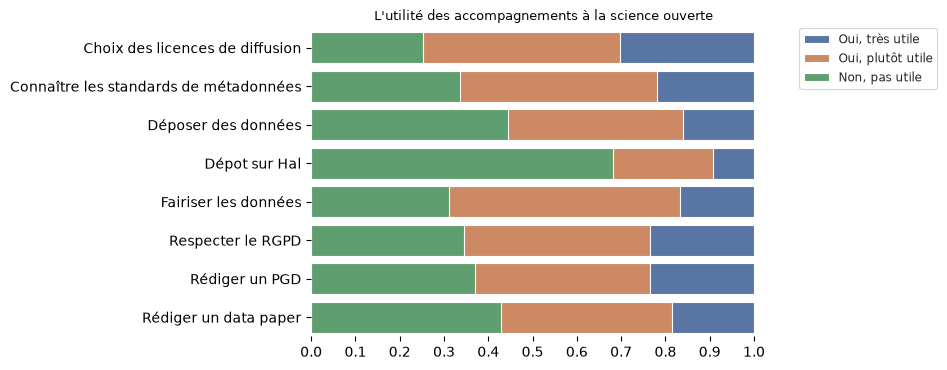

In [23]:
fig, ax = plt.subplots(1, figsize=(6,4))

sns.set_theme(style="ticks", context="paper")

   
g = sns.barplot(x="nb", y="accomp_name", data=q8_dis, hue="interet_accomp", dodge=False)

titre = "L'utilité des accompagnements à la science ouverte"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set_xticks(ticks = [x/10 for x in range(11)])
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))
ax.legend(bbox_to_anchor=(1.05, 1),
                         loc='upper left', borderaxespad=0.)

sns.despine(left=True, bottom=True)
plt.savefig(f"viz/util_accomp_so.png", bbox_inches='tight', dpi = 200)

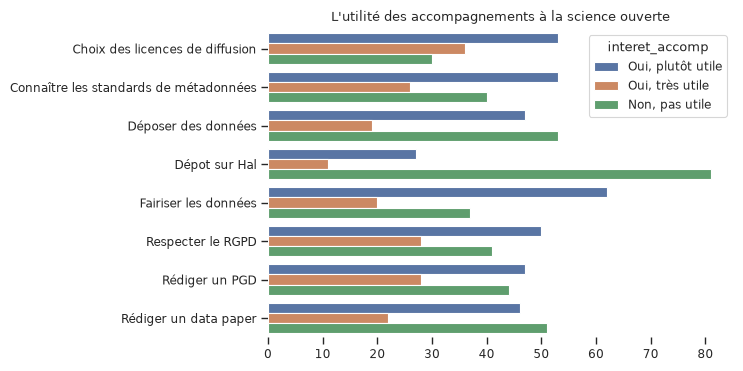

In [24]:
fig, ax = plt.subplots(1, figsize=(6,4))

sns.set_color_codes("pastel")

q8_grp = q8.groupby(["accomp_name","interet_accomp"]).agg(nb=("q45_clé", "size")).sort_values(by=["accomp_name","nb"], ascending=[True, False])

    
sns.barplot(x="nb", y="accomp_name", data=q8_grp, hue="interet_accomp", dodge=True)
titre = "L'utilité des accompagnements à la science ouverte"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))
    

sns.despine(left=True, bottom=True)
#plt.savefig(f"viz/autre_entrepot_rec.png", bbox_inches='tight', dpi = 200)

# Production et analyse des données

## Types de données produites

Les personnes interrogées travaillant exclusivement avec des données dites "quantitatives" sont minoritaires, près de la moitié s'appuient essentiellement sur des données qualitatives et environ un tiers manipulent les deux types de données.

| q11_quali_or_quanti       |   nb |    freq |
|:--------------------------|-----:|--------:|
| Des données qualitatives  |   57 | 47,9 |
| Des données quantitatives |   19 | 16,0 |
| Les deux                  |   43 | 36,1 |
|Total               |119   | 100,0|

Les quatre types de données les plus fréquemment produites sont les entretiens, les données textuelles, les données d'enquête et les données expérimentales ou d'observation. On notera toutefois le caractère ambigü de certaines catégories. Ainsi la notion d'"enquête" est largement utilisé en sciences sociales pour désigner la partie empirique des recherche et peut renvoyer aussi bien aux méthodes d'enquêtes ethnographiques qu'aux méthodes d'enquêtes par questionnaire. De même, les données d'observation peuvent se comprendre au sens de l'anthropologue qui observe les interactions au sein d'un groupe humain  ou de l'ornithologue qui compte les espèces d'oiseau. Parmi les "autres types de données", une personne a d'ailleurs précisé qu'il s'agissait d "observations in situ non expérimentales". Tandis qu'une autre ne se reconnait pas dans la notion de "donnée".



![](viz/type_donnee_quali.png)



In [25]:
quali_or_quanti = grouped_question(df0, column="q11_quali_or_quanti", index = "q45_clé")
print(quali_or_quanti[["q11_quali_or_quanti","nb","freq"]].to_markdown(index=False))


df_exp, type_data = split_multiple_choices(df0, column="q10_type_data", index="q45_clé", sep = '|')
print("\n### Dépôt dans Octaviana détaillé \n", type_data.to_markdown())

| q11_quali_or_quanti       |   nb |    freq |
|:--------------------------|-----:|--------:|
| Des données qualitatives  |   57 | 47.8992 |
| Des données quantitatives |   19 | 15.9664 |
| Les deux                  |   43 | 36.1345 |

### Dépôt dans Octaviana détaillé 
 |    | q10_type_data                           |   nb |   total |     freq |   total_freq |
|---:|:----------------------------------------|-----:|--------:|---------:|-------------:|
|  0 | Données d'entretien                     |   73 |     119 | 61.3445  |          100 |
|  1 | Données textuelles ou documentaires     |   69 |     119 | 57.9832  |          100 |
|  2 | Données d'enquête                       |   63 |     119 | 52.9412  |          100 |
|  3 | Données expérimentales ou d'observation |   62 |     119 | 52.1008  |          100 |
|  4 | Données statistiques                    |   47 |     119 | 39.4958  |          100 |
|  5 | Données multimédia                      |   22 |     119 | 18.4874  |        

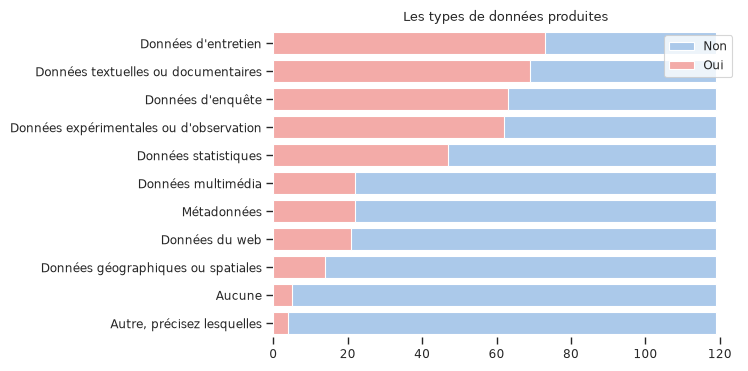

In [26]:
# Initialize the matplotlib figure
fig, ax = plt.subplots(1, figsize=(6,4))

# Plot the total crashes
sns.set_color_codes("pastel")

col= "q10_type_data"
df_exp, gb_data = split_multiple_choices(df0, column=col, index="q45_clé", sep = '|')
sns.barplot(x="total", y=col, data=gb_data,
            label="Non", color="b", ax=ax)
sns.barplot(x="nb", y=col, data=gb_data,
            label="Oui", color="r", ax=ax)
titre = "Les types de données produites"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))
    

sns.despine(left=True, bottom=True)
plt.savefig(f"viz/type_donnee.png", bbox_inches='tight', dpi = 200)

In [27]:
def tab_croise(data, x, y, regroup_y = True, khideux = False) :
    """
    x = variable en ligne
    y = variable en colonne
    """
    if regroup_y == True:

        data.loc[data[y].str.lower().str.contains("oui"), f"{y}_rec"] = "Oui"
        data.loc[data[y].str.lower().str.contains("non"), f"{y}_rec"] = "Non"

        cross_tab = pd.crosstab(data[x], data[f"{y}_rec"], margins = True, margins_name="Total", normalize=False)
        cross_tab0 = pd.crosstab(data[x], data[f"{y}_rec"], margins = False)
    else:
        cross_tab = pd.crosstab(data[x], data[y], margins = True, margins_name="Total", normalize=False)
        cross_tab0 = pd.crosstab(data[x], data[y], margins = False, normalize=False)

    if khideux == True:
        print(scipy.stats.chi2_contingency(cross_tab0))
        st_chi2, st_p, st_dof, st_exp = scipy.stats.chi2_contingency(cross_tab0)
        chi2 = pd.DataFrame(data={"stats":["chi2","df","p-value"], "values":[st_chi2, st_dof, st_p]})
        cross_tab = pd.concat([cross_tab, chi2])
    else:
        pass

    return cross_tab.fillna("").reset_index(), cross_tab0

In [28]:
col= "q10_type_data"
df_exp, gb_data = split_multiple_choices(df0, column=col, index="q45_clé", sep = '|')
df_exp.q10_type_data

0      Données expérimentales ou d'observation
0                          Données d'entretien
0          Données textuelles ou documentaires
0                           Données multimédia
1                                  Métadonnées
                        ...                   
117                             Données du web
117                       Données statistiques
117                         Données multimédia
118    Données expérimentales ou d'observation
118        Données textuelles ou documentaires
Name: q10_type_data, Length: 402, dtype: object

In [29]:
cross_tab, cross_tab0 = tab_croise(df_exp,  "q10_type_data", "q11_quali_or_quanti", regroup_y = False, khideux = False)
q10 = cross_tab0.cumsum(axis=1).stack().reset_index(name='nb').sort_values(by=["nb", "q11_quali_or_quanti"],  ascending=[False, False])
cross_tab.sort_values(by=["Total"],  ascending=[False])

q11_quali_or_quanti,q10_type_data,Des données qualitatives,Des données quantitatives,Les deux,Total
11,Total,174,49,179,402
3,Données d'entretien,36,8,29,73
9,Données textuelles ou documentaires,43,2,24,69
2,Données d'enquête,32,9,22,63
5,Données expérimentales ou d'observation,25,14,23,62
8,Données statistiques,7,10,30,47
7,Données multimédia,9,1,12,22
10,Métadonnées,5,1,16,22
4,Données du web,7,1,13,21
6,Données géographiques ou spatiales,7,1,6,14


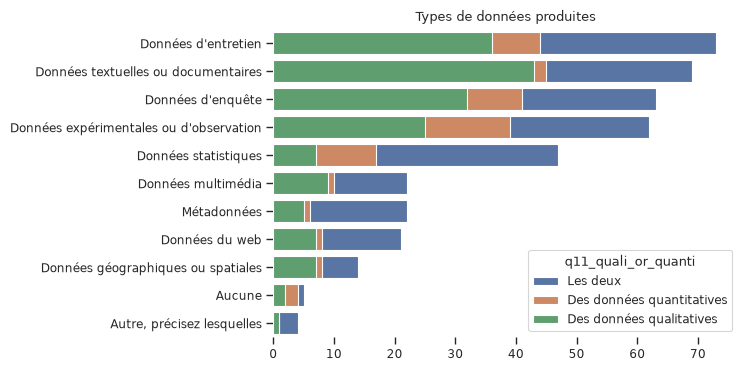

In [30]:
fig, ax = plt.subplots(1, figsize=(6,4))

sns.set_theme(style="ticks", context="paper")

   
g = sns.barplot(x="nb", y="q10_type_data", data=q10, hue="q11_quali_or_quanti", dodge=False)

titre = "Types de données produites"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
#ax.set_xticks(ticks = [x/10 for x in range(11)])
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))


sns.despine(left=True, bottom=True)
plt.savefig(f"viz/type_donnee_quali.png", bbox_inches='tight', dpi = 200)

## Autres types de données

In [31]:
for x in df0.q10_other_type_data.loc[~df0.q10_other_type_data.isna()]:
    print(x)

Observations in situ non expérimentales
Images
données orales, multimodales et visuo-gestuelles
pourquoi ce terme de "données" hérité des sciences dures et qui ne recoupe pas le travail dans la plupart des humanités ou dont je n'ai pas envie de me servir pour décrire ma recherche + désambiguisez tous les acronymes cf TGIR


## Outils de traitement



In [32]:
i=-1
for x in df_col.label.loc[(df_col.question_family=="q5")& (~df_col.label.str.contains("q5_1"))]:
    i+=1
    gb_data0 = grouped_question(df0, column=x, index = "q45_clé")
    gb_data = gb_data0.loc[gb_data0[x]=="Oui"]
    gb_data.loc[gb_data[x]=="Oui", "logiciel_traitement"] = x.replace("q5_","")
    
    if i == 0:
        gb_q5 = gb_data.drop(columns=[x])#.copy()
    else:
        gb_q5 = pd.concat([gb_q5, gb_data.drop(columns=[x])])
    print(gb_data[[x,"nb","freq"]].to_markdown(index=False))


| q5_r   |   nb |    freq |
|:-------|-----:|--------:|
| Oui    |   38 | 31.9328 |
| q5_python   |   nb |    freq |
|:------------|-----:|--------:|
| Oui         |   23 | 19.3277 |
| q5_excel   |   nb |    freq |
|:-----------|-----:|--------:|
| Oui        |   79 | 66.3866 |
| q5_julia   |   nb |    freq |
|:-----------|-----:|--------:|
| Oui        |    2 | 1.68067 |
| q5_stata   |   nb |    freq |
|:-----------|-----:|--------:|
| Oui        |    4 | 3.36134 |
| q5_sas   |   nb |    freq |
|:---------|-----:|--------:|
| Oui      |    3 | 2.52101 |
| q5_aucun   |   nb |   freq |
|:-----------|-----:|-------:|
| Oui        |   15 | 12.605 |
| q5_autre   |   nb |    freq |
|:-----------|-----:|--------:|
| Oui        |   37 | 31.0924 |


/tmp/ipykernel_1092/1307973079.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gb_data.loc[gb_data[x]=="Oui", "logiciel_traitement"] = x.replace("q5_","")
/tmp/ipykernel_1092/1307973079.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gb_data.loc[gb_data[x]=="Oui", "logiciel_traitement"] = x.replace("q5_","")
/tmp/ipykernel_1092/1307973079.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

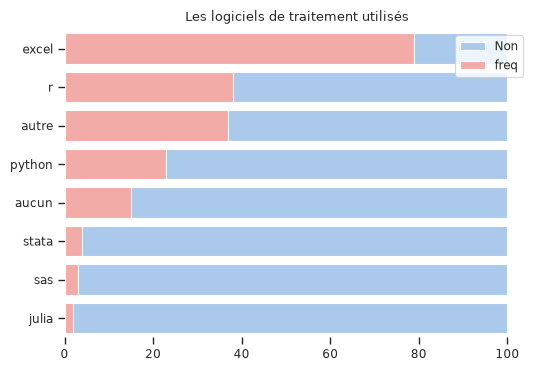

In [33]:
# Initialize the matplotlib figure
fig, ax = plt.subplots(1, figsize=(6,4))

# Plot the total crashes
sns.set_color_codes("pastel")

col = "logiciel_traitement"
sns.barplot(x="total_freq", y=col, data=gb_q5.sort_values("nb", ascending=False),
            label="Non", color="b", ax=ax)
sns.barplot(x="nb", y=col, data=gb_q5.sort_values("nb", ascending=False),
            label="freq", color="r", ax=ax)
titre = "Les logiciels de traitement utilisés"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))
    

sns.despine(left=True, bottom=True)
plt.savefig(f"viz/logiciel_traitement.png", bbox_inches='tight', dpi = 200)

In [34]:
rec_other_lang ={}
for x in df0.q5_1_other_lang.loc[~df0.q5_1_other_lang.isna()]:
    rec_other_lang[x] = x.lower().replace(", ","|")

rec_other_lang

{'MaxQda, EndNotes, Zotero, ': 'maxqda|endnotes|zotero|',
 '\u200b-': '\u200b-',
 'Matlab': 'matlab',
 'Zotero': 'zotero',
 'LibreOffice Calc': 'libreoffice calc',
 'csv, google sheets': 'csv|google sheets',
 'Jamovi, Iramuteq, Qualcoder': 'jamovi|iramuteq|qualcoder',
 'Nvivo': 'nvivo',
 'php, javascript, d3.js': 'php|javascript|d3.js',
 'Jamovi': 'jamovi',
 'JAMOVI ': 'jamovi ',
 'c#': 'c#',
 'SPSS, Statistica, Jamovi, JASP': 'spss|statistica|jamovi|jasp',
 'Nvivo, IA': 'nvivo|ia',
 'Nvivo et Atlas.ti': 'nvivo et atlas.ti',
 'SPSS': 'spss',
 'OCaml, C, Bash, PHP': 'ocaml|c|bash|php',
 'CSS, html, xml': 'css|html|xml',
 'LaTeX': 'latex',
 'NVivo': 'nvivo',
 'MatLab': 'matlab',
 "QGIS. J'aimerais utiliser Python, mais il faudrait que je sois formée pour en avoir les bases. J'ai déjà suivi la formation de base de R proposée à P8, qui était bien : reste maintenant à se l'approprier !": "qgis. j'aimerais utiliser python|mais il faudrait que je sois formée pour en avoir les bases. j'ai déjà

In [35]:
rec_other_lang = {'MaxQda, EndNotes, Zotero, ': 'maxqda|endnotes|zotero',
 '\u200b-': 'aucun',
 'Matlab': 'matlab',
 'Zotero': 'zotero',
 'LibreOffice Calc': 'libreoffice calc',
 'csv, google sheets': 'csv|google sheets',
 'Jamovi, Iramuteq, Qualcoder': 'jamovi|iramuteq|qualcoder',
 'Nvivo': 'nvivo',
 'php, javascript, d3.js': 'php|javascript|d3.js',
 'Jamovi': 'jamovi',
 'JAMOVI ': 'jamovi',
 'c#': 'c#',
 'SPSS, Statistica, Jamovi, JASP': 'spss|statistica|jamovi|jasp',
 'Nvivo, IA': 'nvivo|ia',
 'Nvivo et Atlas.ti': 'nvivo|atlas.ti',
 'SPSS': 'spss',
 'OCaml, C, Bash, PHP': 'ocaml|c/c++|bash|php',
 'CSS, html, xml': 'css|html|xml',
 'LaTeX': 'latex',
 'NVivo': 'nvivo',
 'MatLab': 'matlab',
 "QGIS. J'aimerais utiliser Python, mais il faudrait que je sois formée pour en avoir les bases. J'ai déjà suivi la formation de base de R proposée à P8, qui était bien : reste maintenant à se l'approprier !": "qgis",
 'Access': 'access',
 'File maker pro': 'file maker pro',
 'LibreOffice Calc, Limesurvey, Grist, ActiveTigger, Neo4j, Gephi': 'libreoffice calc|limesurvey|grist|activetigger|neo4j|gephi',
 'Jamovi, SPSS': 'jamovi|spss',
 'C/C++ Cuda Caml Racket Ludii GDL ASP': 'c/c++|cuda|caml|racket|ludii|gdl|asp',
 'R mais avec Iramutex': 'iramuteq',
 'jamovi': 'jamovi',
 'QSR NVivo': 'nvivo',
 'Mplus, SPSS..': 'mplus|spss'}



df0["q5_1_other_lang_rec"]= df0.q5_1_other_lang.map(rec_other_lang.get)

# on enregistre les nouvelles variables dans le dataframe original
#with fs.open(f"{BUCKET_OUT}/data_eP8/raw/anonymous_answer_2026-05-11.csv", "w") as file_out:
#    df0.to_csv(file_out, sep=",", index= False)


In [36]:
dic_new_var = {'name':'14. other_lang',
               'label':'q5_1_other_lang_rec',
               'group':'4_logiciel_traitement',
               'personal_data':False,
               'type':'multiple_choice',
               'opened_question':False,
               'type_panda':df0.q5_1_other_lang_rec.dtypes,
               'no_question':14,
               'question':df_col.question.loc[df_col.label=="q5_1_other_lang"].iloc[0],
               "question_family":df_col.question_family.loc[df_col.label=="q5_1_other_lang"].iloc[0],
               'comment':"Recodage de la question 14. mise en basse casse des logiciels cités."
              }
new_variable = pd.DataFrame.from_dict(data=[dic_new_var])
new_variable
df_col = pd.concat([df_col,new_variable], ignore_index = True)
df_col

,name,label,group,personal_data,type,opened_question,type_panda,no_question,question,question_family,comment
0,N°Obs,qno_obs,NaN,False,numérique,False,int64,0.0,NaN,qno,NaN
1,1. so_principles,q1_so_principles,1_connaissance_so,False,ordinal,False,object,1.0,1/ Diriez-vous que vous êtes familier.ère des ...,q1,NaN
2,2. hal_depot,q2_hal_depot,1_connaissance_so,False,ordinal,False,object,2.0,2/ Avez-vous déjà déposé une production scient...,q2,NaN
3,3. octavi_depot,q3_octavi_depot,2_bib_num,False,nominal_multiple,False,object,3.0,3/ Avez-vous des productions déposées sur Octa...,q3,NaN
4,4. open_data,q4_diff_data,3_entrepot,False,nominal_multiple,False,object,4.0,4/ Avez-vous déjà diffusé vos données de reche...,q4,NaN
...,...,...,...,...,...,...,...,...,...,...,...
159,"5.rec Autre, précisez",q4_autres_entrepots_rec,3_entrepot,False,nominal_multiple,False,object,4.0,4/ Avez-vous déjà diffusé vos données de reche...,q4,NaN
160,16. dev_exemple,q6_1_rec_exemple,5_developpement,False,simple_nominal,False,object,16.0,"6.1/ Si oui, pourriez-vous expliquer ce que vo...",q6,Recodage de la question 16. Se concentre sur l...
161,16. dev_exemple,q6_1_rec_how,5_developpement,False,simple_nominal,False,object,16.0,"6.1/ Si oui, pourriez-vous expliquer ce que vo...",q6,Recodage de la question 16. Précise si un lang...
162,16. dev_exemple,q6_1_rec_how,5_developpement,False,simple_nominal,False,object,16.0,"6.1/ Si oui, pourriez-vous expliquer ce que vo...",q6,Recodage de la question 16. Restitue le but de...


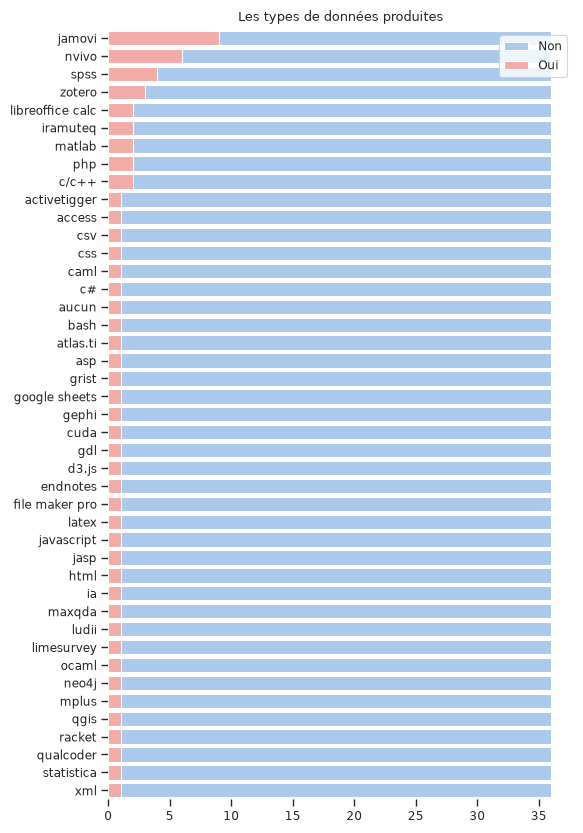

In [37]:
# Initialize the matplotlib figure
fig, ax = plt.subplots(1, figsize=(6,10))

# Plot the total crashes
sns.set_color_codes("pastel")

q5_1 = df0.loc[~df0.q5_1_other_lang_rec.isna()]
col= "q5_1_other_lang_rec"
df_exp, gb_data = split_multiple_choices(q5_1, column=col, index="q45_clé", sep = '|')
sns.barplot(x="total", y=col, data=gb_data,
            label="Non", color="b", ax=ax)
sns.barplot(x="nb", y=col, data=gb_data,
            label="Oui", color="r", ax=ax)
titre = "Les types de données produites"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))
    

sns.despine(left=True, bottom=True)
#plt.savefig(f"viz/type_donnee.png", bbox_inches='tight', dpi = 200)

In [38]:
list_other_logi = [x for x in df_exp.q5_1_other_lang_rec.unique()]
print(list_other_logi)

['maxqda', 'endnotes', 'zotero', 'aucun', 'matlab', 'libreoffice calc', 'csv', 'google sheets', 'jamovi', 'iramuteq', 'qualcoder', 'nvivo', 'php', 'javascript', 'd3.js', 'c#', 'spss', 'statistica', 'jasp', 'ia', 'atlas.ti', 'ocaml', 'c/c++', 'bash', 'css', 'html', 'xml', 'latex', 'qgis', 'access', 'file maker pro', 'limesurvey', 'grist', 'activetigger', 'neo4j', 'gephi', 'cuda', 'caml', 'racket', 'ludii', 'gdl', 'asp', 'mplus']


In [39]:
family_logi = {'maxqda':'CAQDAS', 
               'endnotes':'gestion biblio', 
               'zotero':'gestion biblio', 
               'aucun':'aucun', 
               'matlab':'script et programmation', 
               'libreoffice calc':'feuille de calcul', 
               'csv':'feuille de calcul', 
               'google sheets':'feuille de calcul',
               'jamovi':'logiciels de stats',
               'iramuteq':'analyse de texte', 
               'qualcoder':'CAQDAS',
               'nvivo':'CAQDAS',
               'php':'développement web', 
               'javascript':'développement web',
               'd3.js':'développement web', 
               'c#':'script et programmation', 
               'spss':'logiciels de stats',
               'statistica':'logiciels de stats',
               'jasp':'logiciels de stats',
               'ia':'ia', 
               'atlas.ti':'CAQDAS',
               'ocaml':'script et programmation', 
               'c/c++':'script et programmation',
               'bash':'script et programmation',
               'css':'développement web',
               'html':'développement web', 
               'xml':'développement web',
               'latex':'script et programmation',
               'qgis':'cartographie',
               'access':'gestion de base de donnée',
               'file maker pro':'gestion de base de donnée',
               'limesurvey':'logiciel d\'enquête statistique',
               'grist':'gestion de base de donnée',
               'activetigger':'analyse de texte',
               'neo4j':'gestion de base de donnée',
               'gephi':'analyse de réseau',
               'cuda':'script et programmation', 
               'caml':'script et programmation', 
               'racket':'script et programmation', 
               'ludii':'création de jeu',
               'gdl':'logiciels de stats',
               'asp':'développement web',
               'mplus': 'logiciels de stats',
               'excel': 'feuille de calcul',
               'python': 'script et programmation',
               'r':'script et programmation',
               'stata':'logiciels de stats',
               'julia': 'script et programmation',
               'sas': 'logiciels de stats'
              }

In [40]:
df01 = df0.copy()

dict_logiciel_traitement = {}
for row in df0.q45_clé:
    logiciel_traitement = []
    for x in df_col.label.loc[(df_col.question_family=="q5")& (~df_col.label.str.contains("q5_1"))]:
        if df01[x].loc[df01.q45_clé==row].values == "Oui":
            logiciel_traitement.append(x.lower().replace("q5_",""))
    if len(logiciel_traitement)>0:
        dict_logiciel_traitement[row]= '|'.join(logiciel_traitement)
df01["q5_logiciel_traitement_rec"] = df01.q45_clé.map(dict_logiciel_traitement)



In [41]:
df0
df_exp, gb_data = split_multiple_choices(df01.loc[~df01.q5_logiciel_traitement_rec.isna()], column='q5_logiciel_traitement_rec', index="q45_clé", sep = '|')
df_exp1, gb_data1 = split_multiple_choices(df01.loc[~df01.q5_1_other_lang_rec.isna()], column='q5_1_other_lang_rec', index="q45_clé", sep = '|')

df_exp2 = pd.concat([df_exp[["q45_clé", 'q5_logiciel_traitement_rec']], df_exp1[["q45_clé","q5_1_other_lang_rec"]].rename(columns={"q5_1_other_lang_rec":'q5_logiciel_traitement_rec'})])
df_exp2["q5_family_logi"]= df_exp2.q5_logiciel_traitement_rec.map(family_logi.get)
df_exp3 = df_exp2.loc[~df_exp2.q5_logiciel_traitement_rec.isin(["aucun","autre"])]
df_exp3

,q45_clé,q5_logiciel_traitement_rec,q5_family_logi
2,FCCB-GMYA,excel,feuille de calcul
3,CV3G-95CT,r,script et programmation
4,M5L8-UM9F,r,script et programmation
4,M5L8-UM9F,excel,feuille de calcul
5,HT8V-PSKZ,python,script et programmation
...,...,...,...
95,7CU7-JG8K,iramuteq,analyse de texte
104,A7R6-3SWC,jamovi,logiciels de stats
111,Q934-QKAW,nvivo,CAQDAS
112,HKN6-95PQ,mplus,logiciels de stats


In [42]:
gb_data = df_exp3.groupby(["q5_family_logi", "q5_logiciel_traitement_rec"]).agg(nb=("q45_clé","size")).sort_values(["q5_family_logi","nb"], ascending=[False,False]).reset_index()

,q5_family_logi,q5_logiciel_traitement_rec,nb
0,script et programmation,r,38
1,script et programmation,python,23
2,script et programmation,c/c++,2
3,script et programmation,julia,2
4,script et programmation,matlab,2
5,script et programmation,bash,1
6,script et programmation,c#,1
7,script et programmation,caml,1
8,script et programmation,cuda,1
9,script et programmation,latex,1


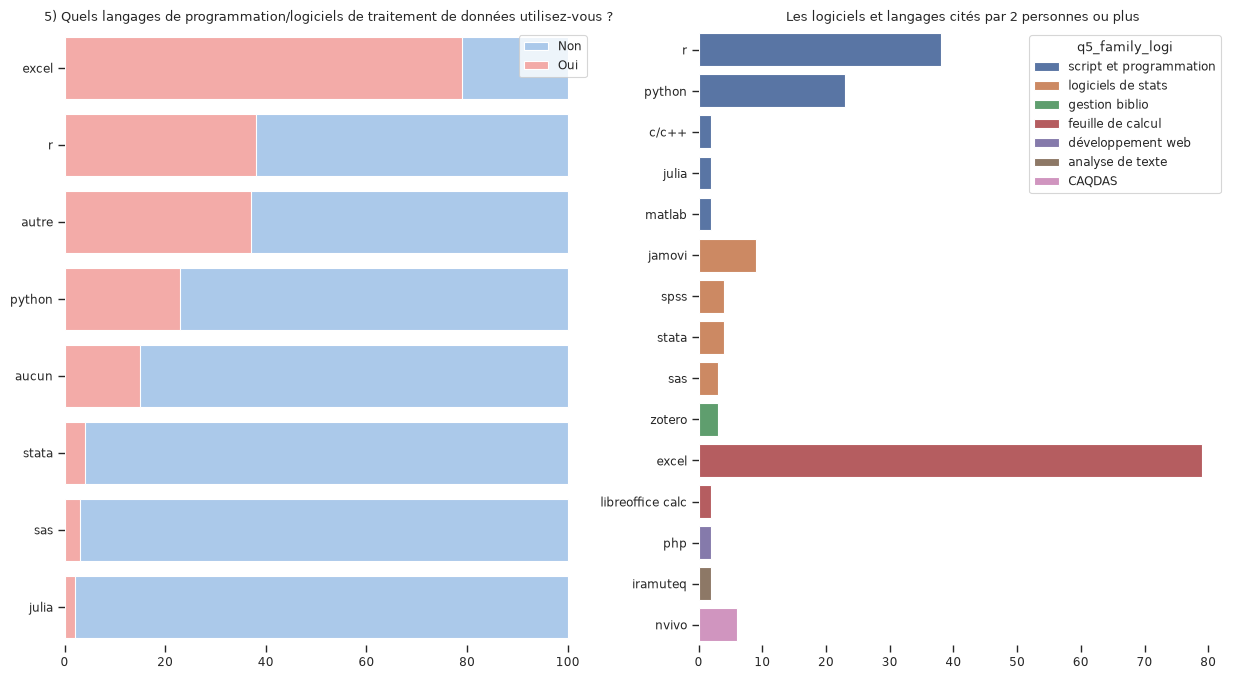

In [43]:
# Initialize the matplotlib figure
fig, ax = plt.subplots(1, 2, figsize=(15,8))

# Plot the total crashes
sns.set_color_codes("pastel")


col = "logiciel_traitement"
sns.barplot(x="total_freq", y=col, data=gb_q5.sort_values("nb", ascending=False),
            label="Non", color="b", ax=ax[0])
sns.barplot(x="nb", y=col, data=gb_q5.sort_values("nb", ascending=False),
            label="Oui", color="r", ax=ax[0])
titre = "5) Quels langages de programmation/logiciels de traitement de données utilisez-vous ?"
ax[0].yaxis.set_label_text("")
ax[0].xaxis.set_label_text("")
ax[0].set_title(titre.replace("<i>","(").replace("</i>",")"))

gb_data2 = gb_data.loc[gb_data.nb>1]
sns.barplot(x="nb", y="q5_logiciel_traitement_rec", data=gb_data2,
            hue="q5_family_logi", ax=ax[1])
titre = "Les logiciels et langages cités par 2 personnes ou plus"
ax[1].yaxis.set_label_text("")
ax[1].xaxis.set_label_text("")
ax[1].set_title(titre.replace("<i>","(").replace("</i>",")"))
    

sns.despine(left=True, bottom=True)
plt.savefig(f"viz/logiciel_traitement_use_by_2people.png", bbox_inches='tight', dpi = 200)

Le graphique ci-dessous donne à voir les logiciels qui sont cités par plus de deux répondants. Il regroupe les questions 5 et 5.1 sur les logiciels et langages utilisés pour le traitement des données. La question 5 proposait 6 outils : Excel, R, python, SAS, Stata et Julia. Pour chacun de ces outils, les personnes interrogées devaient répondre si elles les utilisaient ou non. Avec la question 5.1, elles pouvaient ensuite compléter leur réponse en donnant le nom d'autres outils informatiques. Les 36 personnes qui ont répondu à la question 5.1 ont ainsi cité 26 autres logiciels et langages, ce qui fait au total 48  outils informatiques différents. Pour faciliter la lecture, nous les avons regroupés par "familles". On retrouve ainsi :

* les "logiciels de statistiques" comme SPSS, Jamovi, Stata ;
* les langages de "scripts et de programmations" comme R, Python, Matlab ou C++. Probablement qu'une subdivision de cette catégorie serait justifiée afin de distinguer les langages généralement employés pour l'analyse de données (R, Julia, Matlab, Python) et les langages de programmation comme C++ ;
* les outils de gestion de bibliographie (Zotero, Endnote) ;
* les logiciels de "tableurs" et les feuilles de calculs : Excel, Libre Calc ;
* les langages liés au développement web (css, html, php, javascript) ;
* les outils d'analyse textuelle (Iramuteq, ActiveTigger) ;
* les "CAQDAS" (Computer-Assisted Qualitative Data Analysis Software) comme Nvivo, Qualcoder, Atlas.ti

En termes d'utilisateurs, Excel est l'outil le plus répendu. Deux tiers des répondants (N=79) y recourent pour traiter leurs données. Ce sont ensuite les langage R (N=38) et Python (N=23) qui sont les plus utilisés. Jamovi (N=9) est le plus cité des logiciels d'analyse statistique, comme Nvivo (N=6) pour les logiciels CAQDAS. On note par ailleurs qu'une peronne sur cinq dit n'utiliser aucun outil informatique pour traiter les données.


![](viz/logiciel_traitement_use_by_2people.png)


In [44]:
df01 = df0.copy()

dict_logiciel_traitement2 = {}
dict_logiciel_fam = {}
for row in df_exp3.q45_clé:
    
    dftmp = df_exp3.loc[df_exp3.q45_clé==row]
    logiciel_traitement2 = [x for x in dftmp.q5_logiciel_traitement_rec.unique()]
    family_logi = [x for x in dftmp.q5_family_logi.unique()]
    dict_logiciel_traitement2[row] = "|".join(logiciel_traitement2)
    dict_logiciel_fam[row] = "|".join(family_logi)


In [46]:
df0["q5_logiciel_traitement_rec"]= df0.q45_clé.map(dict_logiciel_traitement2.get)
df0["q5_family_logi"] = df0.q45_clé.map(dict_logiciel_fam.get)


# on enregistre les nouvelles variables dans le dataframe original
with fs.open(f"{BUCKET_OUT}/data_eP8/raw/anonymous_answer_2026-07-24.csv", "w") as file_out:
    df0.to_csv(file_out, sep=",", index= False)


In [77]:
df_col1 = df_col.iloc[0:-5]
df_col1

,name,label,group,personal_data,type,opened_question,type_panda,no_question,question,question_family,comment
0,N°Obs,qno_obs,NaN,False,numérique,False,int64,0.0,NaN,qno,NaN
1,1. so_principles,q1_so_principles,1_connaissance_so,False,ordinal,False,object,1.0,1/ Diriez-vous que vous êtes familier.ère des ...,q1,NaN
2,2. hal_depot,q2_hal_depot,1_connaissance_so,False,ordinal,False,object,2.0,2/ Avez-vous déjà déposé une production scient...,q2,NaN
3,3. octavi_depot,q3_octavi_depot,2_bib_num,False,nominal_multiple,False,object,3.0,3/ Avez-vous des productions déposées sur Octa...,q3,NaN
4,4. open_data,q4_diff_data,3_entrepot,False,nominal_multiple,False,object,4.0,4/ Avez-vous déjà diffusé vos données de reche...,q4,NaN
...,...,...,...,...,...,...,...,...,...,...,...
155,155. Appareil utilisé pour la saisie,q54_appareil_utilisé_pour_la_saisie,17_metadonnee,False,simple_nominal,False,object,NaN,NaN,q54,NaN
156,110. statut_rec,q25_statut_rec,12_descript_repondant,False,simple_nominal,False,object,25.0,2/ Êtes-vous ?,q25,NaN
157,110. doctorant,q25_doctorant,12_descript_repondant,False,simple_nominal,False,bool,25.0,2/ Êtes-vous ?,q25,NaN
158,3. octavi_depot_rec,q3_octavi_rec,2_bib_num,False,simple_nominal,False,object,3.0,3/ Avez-vous des productions déposées sur Octa...,q3,NaN


In [78]:
dic_new_var = {'name':'13.1 logiciel de traitment',
               'label':'q5_logiciel_traitement_rec',
               'group':'4_logiciel_traitement',
               'personal_data':False,
               'type':'multiple_choice',
               'opened_question':False,
               'type_panda':df0.q5_logiciel_traitement_rec.dtypes,
               'no_question':5,
               'question':df_col.question.loc[df_col.label=="q5_r"].iloc[0],
               "question_family":df_col.question_family.loc[df_col.label=="q5_r"].iloc[0],
               'comment':"Regroupe les questions 5 et 6 sur les logiciels de traitement"
              }
new_variable = pd.DataFrame.from_dict(data=[dic_new_var])
new_variable
df_col1 = pd.concat([df_col1,new_variable], ignore_index = True)
df_col1

dic_new_var = {'name':'13.2 familles de logiciel',
               'label':'q5_family_logi',
               'group':'4_logiciel_traitement',
               'personal_data':False,
               'type':'multiple_choice',
               'opened_question':False,
               'type_panda':df0.q5_family_logi.dtypes,
               'no_question':5,
               'question':df_col.question.loc[df_col.label=="q5_r"].iloc[0],
               "question_family":df_col.question_family.loc[df_col.label=="q5_r"].iloc[0],
               'comment':"Classe les logiciels par famille"
              }
new_variable = pd.DataFrame.from_dict(data=[dic_new_var])
new_variable
df_col1 = pd.concat([df_col1,new_variable], ignore_index = True)
df_col1

,name,label,group,personal_data,type,opened_question,type_panda,no_question,question,question_family,comment
0,N°Obs,qno_obs,NaN,False,numérique,False,int64,0.0,NaN,qno,NaN
1,1. so_principles,q1_so_principles,1_connaissance_so,False,ordinal,False,object,1.0,1/ Diriez-vous que vous êtes familier.ère des ...,q1,NaN
2,2. hal_depot,q2_hal_depot,1_connaissance_so,False,ordinal,False,object,2.0,2/ Avez-vous déjà déposé une production scient...,q2,NaN
3,3. octavi_depot,q3_octavi_depot,2_bib_num,False,nominal_multiple,False,object,3.0,3/ Avez-vous des productions déposées sur Octa...,q3,NaN
4,4. open_data,q4_diff_data,3_entrepot,False,nominal_multiple,False,object,4.0,4/ Avez-vous déjà diffusé vos données de reche...,q4,NaN
...,...,...,...,...,...,...,...,...,...,...,...
157,110. doctorant,q25_doctorant,12_descript_repondant,False,simple_nominal,False,bool,25.0,2/ Êtes-vous ?,q25,NaN
158,3. octavi_depot_rec,q3_octavi_rec,2_bib_num,False,simple_nominal,False,object,3.0,3/ Avez-vous des productions déposées sur Octa...,q3,NaN
159,"5.rec Autre, précisez",q4_autres_entrepots_rec,3_entrepot,False,nominal_multiple,False,object,4.0,4/ Avez-vous déjà diffusé vos données de reche...,q4,NaN
160,13.1 logiciel de traitment,q5_logiciel_traitement_rec,4_logiciel_traitement,False,multiple_choice,False,object,5.0,"5/ Dans le cadre de vos travaux de recherche, ...",q5,Regroupe les questions 5 et 6 sur les logiciel...



## Développement et dépôt de codes ou de logiciels

In [48]:
dev_code= grouped_question(df0, column="q6_dev_code", index = "q45_clé")
print(dev_code)

df_exp, sw_depot2 = split_multiple_choices(df0, column="q7_software_depot", index="q45_clé", sep = '|')
print("\n### Ouverture du code \n", sw_depot2.to_markdown())

  q6_dev_code  nb  total       freq  total_freq
0         Non  87    119  73.109244       100.0
1         Oui  32    119  26.890756       100.0

### Ouverture du code 
 |    | q7_software_depot          |   nb |   total |      freq |   total_freq |
|---:|:---------------------------|-----:|--------:|----------:|-------------:|
|  0 | Non                        |   89 |     119 | 74.7899   |          100 |
|  1 | Oui, sur GitHub            |   23 |     119 | 19.3277   |          100 |
|  2 | Oui, sur GitLab            |   12 |     119 | 10.084    |          100 |
|  3 | Oui, autre, précisez       |    6 |     119 |  5.04202  |          100 |
|  4 | Oui, sur Software Heritage |    1 |     119 |  0.840336 |          100 |


Parallèlement  à l'utilisation d'outils informatiques pour le traitement des données, près d'un quart des répondants ont déjà été amenés à développer ou faire développer du code ou des logiciels dans le cadre de leurs recherches, dont deux n'ont jamais déposé leur code ou logiciel sur un entrepot dédié.

Si le dépôt de code sur Github et Gitlab restent les solutions les plus usitées, 6 personnes déposent leus codes et logiciels ailleurs : 
* "Sur les dépôts SSC des commandes Stata";
* "sur des repositories personnels";
* "sur Hal";
* "sur Ortolang et Huma-Num",
* "Sur des instances auto-hébergées de Gitlab"
* ou "sur l'INPI".


Sur les 32 personnes ayant répondu "Oui" à la question "êtes-vous amené.e à développer ou faire développer des logiciels/du code spécialisé(s) ?", 31 ont donnée des indications plus ou moins précises sur ce qu'elles développent ou font développer en répondant à la question 16. Nous avons analysé les réponses manuellement. On a ainsi 8 personnes qui disent développer des "logiciels variés", des "algorithmes" ou encore des "plateformes, programmes logiciels, œuvres" sans données d'autres précisions. Les chercheurs qui manipulent du code afin de traiter et d'analyser les données constituent le groupe le plus importants (N=14). On observe enfin un petit groupe de personnes (N=7) construisant des outils liés à la collecte de données d'expérience via des jeux ou le logiciel Psytoolkit. 

| Type de développement                  |   nb |   total |   freq |
|:---------------------------------|-----:|--------:|-------:|
| traitement et analyse de données |   15 |      31 |   48,4 |
| programmes et logiciels variés   |    8 |      31 |   25,8 |
| collecte de données              |    7 |      31 |   22,6 |
| diffusion                        |    2 |      31 |    6,5 |


In [102]:
rec_code={
    "Mes activités de recherche consist à développer des outils spécialisés pour le traitement de la parole et l'analyse des médias":
    {"what":"traitement du son","group":"traitement et analyse de données", "how":""},
    
    "des apps web": 
    {"what":"applications web","group":"programmes et logiciels variés", "how":""},
    
    "Des logiciels variés, allant du materiel d'expérience à des productions directes à être diffusées.":
    {"what":"outils d'expériences", "group":"collecte de données|programmes et logiciels variés", "how":""},
    
    "Questionnaires et programmes d'expérience sur Psytoolkit":
    {"what":"outils d'expérience","group":"collecte de données", "how":"psychtoolkit"},
    
    "Beaucoup d'outils cf. https://samszo.jardindesconnaissances.fr/HDR/cv/cv.html#sec-item299386":
     {"what":"", "group":"programmes et logiciels variés", "how":""},
    
    "Les Commades Stata":
    {"what":"des commandes stata", "group":"traitement et analyse de données", "how":"Stata"},
    
    "Plugin de moteur temps réel pour la XR.":
    {"what":"plugins pour réalité virtuelle", "group":"programmes et logiciels variés", "how":""},
    
    "Je ne l'ai pas fait moi-même mais à grenoble je travaille avec les ingénieurs de la PUD pour fabriqueur un outil semi automatique de pseudonymisation.":
    {"what":"outils de pseudonymisation", "group": "traitement et analyse de données","how":""},
    
    "Une librairie Julia pour du traitement de réseaux.":
    {"what":"analyse de réseau", "group":"traitement et analyse de données", "how":"Julia"},
    
    "plateformes, programmes logiciels, œuvres":
    {"what":"programmes et logiciels variés", "group":"programmes et logiciels variés", "how":""},
    
    "Logiciels de synthèse et traitement du son":
    {"what":"traitement du son","group":"traitement et analyse de données", "how":""},
    
    "Outil de transcription et d'annotation de données": 
    {"what":"transcription et annotation", "group":"traitement et analyse de données", "how":""},
    
    "https://pablo.rauzy.name/software.html":
    {"what":"", "group":"programmes et logiciels variés","how":""},
    
    "création de site internet pour valorisation et diffusion des activités de recherche, productions des étudiants, etc": 
    {"what":"sites web", "group": "diffusion", "how":""},
    
    "Implémentation d's ou algorithme de démonstration":
    {"what":"implémentation", "group": "programmes et logiciels variés", "how":""},
    
    "jeu sérieux sur tablette": 
    {"what":"jeu sérieux", "group":"collecte de données", "how":""},
    
    "Développez les scripts/méthodologies pour traiter mes données":
    {"what":"scripts", "group":"traitement et analyse de données", "how":""},
    
    "Plateforme PatriMaths, sémathèque : https://sematheque.ahp-numerique.fr":
    {"what":"plateforme","group":"diffusion","how":""},
    
    "Dans le cadre du consortium Projets Time Machine, plusieurs logiciels/codes spécialisés sont des logiciels: d'analyse morphologique (MorphAL = Analyse morphologique) qui a énté intégrée comme un plug-in dans QGis ; Amado-on-line (logiciel de visualisation des matrices graphiques le suivant de Bertin)":
    {"what":"analyse morphologique", "group":"traitement et analyse de données", "how":"qgis"},
    
    "prédication de C02 dans Paris":
    {"what":" prédiction", "group":"traitement et analyse de données", "how":""},
    "Scripts Python. En ce moment : prestation avec le CERES pour met à jour Digipower Academy, en partenariat avec l'association suisse Personaldata.io":
    {"what":"applications web", "group":"programmes et logiciels variés","how":"python"},
    
    "jouer aux jeux à 1, à 2 et joueurs et + selon les jeux (ou problèmes considérés)":
    {"what":"jeux", "group":"collecte de données", "how":""},
    
    "Des logiciels d'Interaction Humain-Machine transportante des appareils pétéraux d'interactions (recueil de données de protocoles d'interaction)":
    {"what":"logiciels d'interaction humain-machine", "group":"collecte de données", "how":""},
    
    "Des cahiers Jupyter pour l'analyse des données de recherche":
    {"what":"notebook", "group":"traitement et analyse de données","how":"jupyter"},
    
    "Nous avons avec l'INA une IA (gpt-oss-120) pour thématiser de gros cormus de vidéos":
    {"what":"classification automatique", "group":"traitement et analyse de données", "how":"IA générative"},
    
    "une série d'outil de modélisation à base d'approche profond lerning":
    {"what":"modélisation",  "group":"traitement et analyse de données", "how":"deep learning"},
    
    "Dans un projet de recherche je participe à participer, nous faisons réaliser un HTR de formulaires manuscrits.":
    {"what":"reconnaissance de caractère", "group":"traitement et analyse de données","how":""},
    
    "des code pour les expériences à l'aide d'outils type PsychToolkit":
    {"what":"outils d'expérience", "group":"collecte de données", "how":"psychtoolkit"},
    "TEI/XML adapté à une correspondance du xviiie siècle":
    {"what":"transcription et annotation", "group":"traitement et analyse de données","how":"TEI/XML"},
    
    "Base de de donation TOFLLIT18 (issu d'un projet ANR)":
    {"what":"base de données", "group":"collecte de données", "how":""},
    
    "des scripts R pour du traitement d'analyse de despageses":
    {"what":"scripts", "group":"traitement et analyse de données", "how":""}
}

In [103]:
list_exemple_code = [x for x in df0.q6_1_dev_exemple.loc[~df0.q6_1_dev_exemple.isna()]]
new_rec_code = {}
for n, x in enumerate(rec_code):
    new_key = list_exemple_code[n]
    new_rec_code[new_key]= rec_code[x]

new_rec_code


{"Mes activités de recherche consiste à développer des outils spécialisés pour le traitement de la parole et l'analyse des médias": {'what': 'traitement du son',
  'group': 'traitement et analyse de données',
  'how': ''},
 'des apps web': {'what': 'applications web',
  'group': 'programmes et logiciels variés',
  'how': ''},
 "Des logiciels variés, allant du materiel d'expérience à des productions directe visant à être diffusées.": {'what': "outils d'expériences",
  'group': 'collecte de données|programmes et logiciels variés',
  'how': ''},
 "Questionnaires et programmes d'expérimentaiton sur Psytoolkit": {'what': "outils d'expérience",
  'group': 'collecte de données',
  'how': 'psychtoolkit'},
 "Beaucoup d'outils cf. https://samszo.jardindesconnaissances.fr/HDR/cv/cv.html#sec-item299386": {'what': '',
  'group': 'programmes et logiciels variés',
  'how': ''},
 'Des commades Stata': {'what': 'des commandes stata',
  'group': 'traitement et analyse de données',
  'how': 'Stata'},
 'P

In [104]:
list_row= []
for x in new_rec_code:

    id_row = df0.q45_clé.loc[df0.q6_1_dev_exemple==x].values

    if len(id_row) > 0:
        exemple = new_rec_code[x]
        dict_row = {"q45_clé":id_row[0],
              "q6_1_dev_what":exemple["what"].lower(),
              "q6_1_dev_group":exemple["group"].lower(),
              "q6_1_dev_how": exemple["how"].lower()}
        list_row.append(dict_row)

dftp = pd.DataFrame.from_dict(list_row)
dftp


,q45_clé,q6_1_dev_what,q6_1_dev_group,q6_1_dev_how
0,CN6B-UEHQ,traitement du son,traitement et analyse de données,
1,5G5M-BM3L,applications web,programmes et logiciels variés,
2,BKF8-SNEZ,outils d'expériences,collecte de données|programmes et logiciels va...,
3,YTMC-B4DP,outils d'expérience,collecte de données,psychtoolkit
4,ZGPH-2FPH,,programmes et logiciels variés,
5,SKD4-XJMH,des commandes stata,traitement et analyse de données,stata
6,RVX8-7FSV,plugins pour réalité virtuelle,programmes et logiciels variés,
7,E3YL-PHZV,outils de pseudonymisation,traitement et analyse de données,
8,RAUZ-BRFQ,analyse de réseau,traitement et analyse de données,julia
9,QH7Q-PJZ9,programmes et logiciels variés,programmes et logiciels variés,


In [106]:


df01 = df0.merge(dftp, on = ["q45_clé"], how="left")



,qno_obs,q1_so_principles,q2_hal_depot,q3_octavi_depot,q4_diff_data,q4_autres_entrepots,q5_r,q5_python,q5_excel,q5_julia,...,q3_octavi_rec,q4_autres_entrepots_rec,q5_logiciel_traitement_rec,q5_1_other_lang_rec,q5_family_logi,q4_diff_data_grouped,q4_diff_data_rec,q6_1_dev_what,q6_1_dev_group,q6_1_dev_how
0,1,"Oui, un peu","Oui, une fois",Non,Non,NaN,Non,Non,Non,Non,...,Non,NaN,None,None,None,Non,Non,NaN,NaN,NaN
1,2,"Oui, un peu","Oui, une fois",Non,Non,NaN,Non,Non,Non,Non,...,Non,NaN,None,None,None,Non,Non,NaN,NaN,NaN
2,3,"Oui, tout à fait","Oui, plusieurs fois",Je ne connais pas Octaviana,Non,NaN,Non,Non,Oui,Non,...,Non,NaN,excel|maxqda|endnotes|zotero,maxqda|endnotes|zotero,feuille de calcul|CAQDAS|gestion biblio,Non,Non,NaN,NaN,NaN
3,4,"Oui, un peu","Oui, une fois",Non,"Autre, précisez",OSF,Oui,Non,Non,Non,...,Non,osf,r,None,script et programmation,Oui,osf,NaN,NaN,NaN
4,6,"Oui, un peu","Oui, systématiquement",Non;Je ne connais pas Octaviana,Non,NaN,Oui,Non,Oui,Non,...,Non,NaN,r|excel,aucun,script et programmation|feuille de calcul,Non,Non,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,117,"Oui, un peu","Oui, plusieurs fois",Non,"Autre, précisez",OSF,Oui,Oui,Oui,Non,...,Non,osf,r|python|excel,None,script et programmation|feuille de calcul,Oui,osf,NaN,NaN,NaN
115,118,"Oui, un peu","Oui, systématiquement",Non,Non,NaN,Oui,Non,Oui,Non,...,Non,NaN,r|excel,None,script et programmation|feuille de calcul,Non,Non,NaN,NaN,NaN
116,119,"Oui, un peu","Oui, plusieurs fois",Non,Non,NaN,Oui,Non,Oui,Non,...,Non,NaN,r|excel,None,script et programmation|feuille de calcul,Non,Non,scripts,traitement et analyse de données,
117,120,Non,"Oui, plusieurs fois",Non;Je ne connais pas Octaviana,"Autre, précisez",Mendeley data,Non,Oui,Oui,Non,...,Non,mendeley data,python|excel,None,script et programmation|feuille de calcul,Oui,mendeley data,NaN,NaN,NaN


In [107]:
# on enregistre les nouvelles variables dans le dataframe original
with fs.open(f"{BUCKET_OUT}/data_eP8/raw/anonymous_answer_2026-07-24.csv", "w") as file_out:
    df01.to_csv(file_out, sep=",", index= False)

In [80]:
dic_new_var = {'name':'16. dev_exemple',
               'label':'q6_1_dev_what',
               'group':'5_developpement',
               'personal_data':False,
               'type':'simple_nominal',
               'opened_question':False,
               'type_panda':df01.q6_1_dev_what.dtypes,
               'no_question':16,
               'question':df_col.question.loc[df_col.label=="q6_1_dev_exemple"].iloc[0],
               'comment':"Recodage de la question 16. Restitue le type d'objet développé : traitement du son, jeu, base de donnée, site web"
              }
new_variable = pd.DataFrame.from_dict(data=[dic_new_var])
new_variable
df_col1 = pd.concat([df_col1,new_variable], ignore_index = True)
df_col1

,name,label,group,personal_data,type,opened_question,type_panda,no_question,question,question_family,comment
0,N°Obs,qno_obs,NaN,False,numérique,False,int64,0.0,NaN,qno,NaN
1,1. so_principles,q1_so_principles,1_connaissance_so,False,ordinal,False,object,1.0,1/ Diriez-vous que vous êtes familier.ère des ...,q1,NaN
2,2. hal_depot,q2_hal_depot,1_connaissance_so,False,ordinal,False,object,2.0,2/ Avez-vous déjà déposé une production scient...,q2,NaN
3,3. octavi_depot,q3_octavi_depot,2_bib_num,False,nominal_multiple,False,object,3.0,3/ Avez-vous des productions déposées sur Octa...,q3,NaN
4,4. open_data,q4_diff_data,3_entrepot,False,nominal_multiple,False,object,4.0,4/ Avez-vous déjà diffusé vos données de reche...,q4,NaN
...,...,...,...,...,...,...,...,...,...,...,...
158,3. octavi_depot_rec,q3_octavi_rec,2_bib_num,False,simple_nominal,False,object,3.0,3/ Avez-vous des productions déposées sur Octa...,q3,NaN
159,"5.rec Autre, précisez",q4_autres_entrepots_rec,3_entrepot,False,nominal_multiple,False,object,4.0,4/ Avez-vous déjà diffusé vos données de reche...,q4,NaN
160,13.1 logiciel de traitment,q5_logiciel_traitement_rec,4_logiciel_traitement,False,multiple_choice,False,object,5.0,"5/ Dans le cadre de vos travaux de recherche, ...",q5,Regroupe les questions 5 et 6 sur les logiciel...
161,13.2 familles de logiciel,q5_family_logi,4_logiciel_traitement,False,multiple_choice,False,object,5.0,"5/ Dans le cadre de vos travaux de recherche, ...",q5,Classe les logiciels par famille


In [81]:
dic_new_var = {'name':'16. dev_exemple',
               'label':'q6_1_dev_group',
               'group':'5_developpement',
               'personal_data':False,
               'type':'simple_nominal',
               'opened_question':False,
               'type_panda':df01.q6_1_dev_group.dtypes,
               'no_question':16,
               'question':df_col.question.loc[df_col.label=="q6_1_dev_exemple"].iloc[0],
               'comment':"Classe les exemples de logiciels développés dans des groupes : outils de traitement et d'analyse, outils de diffusion, collecte de données, etc."
              }
new_variable = pd.DataFrame.from_dict(data=[dic_new_var])
new_variable
df_col1 = pd.concat([df_col1,new_variable], ignore_index = True)
df_col1

,name,label,group,personal_data,type,opened_question,type_panda,no_question,question,question_family,comment
0,N°Obs,qno_obs,NaN,False,numérique,False,int64,0.0,NaN,qno,NaN
1,1. so_principles,q1_so_principles,1_connaissance_so,False,ordinal,False,object,1.0,1/ Diriez-vous que vous êtes familier.ère des ...,q1,NaN
2,2. hal_depot,q2_hal_depot,1_connaissance_so,False,ordinal,False,object,2.0,2/ Avez-vous déjà déposé une production scient...,q2,NaN
3,3. octavi_depot,q3_octavi_depot,2_bib_num,False,nominal_multiple,False,object,3.0,3/ Avez-vous des productions déposées sur Octa...,q3,NaN
4,4. open_data,q4_diff_data,3_entrepot,False,nominal_multiple,False,object,4.0,4/ Avez-vous déjà diffusé vos données de reche...,q4,NaN
...,...,...,...,...,...,...,...,...,...,...,...
159,"5.rec Autre, précisez",q4_autres_entrepots_rec,3_entrepot,False,nominal_multiple,False,object,4.0,4/ Avez-vous déjà diffusé vos données de reche...,q4,NaN
160,13.1 logiciel de traitment,q5_logiciel_traitement_rec,4_logiciel_traitement,False,multiple_choice,False,object,5.0,"5/ Dans le cadre de vos travaux de recherche, ...",q5,Regroupe les questions 5 et 6 sur les logiciel...
161,13.2 familles de logiciel,q5_family_logi,4_logiciel_traitement,False,multiple_choice,False,object,5.0,"5/ Dans le cadre de vos travaux de recherche, ...",q5,Classe les logiciels par famille
162,16. dev_exemple,q6_1_dev_what,5_developpement,False,simple_nominal,False,object,16.0,"6.1/ Si oui, pourriez-vous expliquer ce que vo...",NaN,Recodage de la question 16. Restitue le type d...


In [90]:
dic_new_var = {'name':'16. dev_exemple',
               'label':'q6_1_dev_how',
               'group':'5_developpement',
               'personal_data':False,
               'type':'simple_nominal',
               'opened_question':False,
               'type_panda':df01.q6_1_dev_how.dtypes,
               'no_question':16,
               'question':df_col.question.loc[df_col.label=="q6_1_dev_exemple"].iloc[0],
               'comment':"Précise le langage ou l'outil de programmation utilisé"
              }
new_variable = pd.DataFrame.from_dict(data=[dic_new_var])
new_variable
df_col1 = pd.concat([df_col1,new_variable], ignore_index = True)
df_col1

,name,label,group,personal_data,type,opened_question,type_panda,no_question,question,question_family,comment
0,N°Obs,qno_obs,NaN,False,numérique,False,int64,0.0,NaN,qno,NaN
1,1. so_principles,q1_so_principles,1_connaissance_so,False,ordinal,False,object,1.0,1/ Diriez-vous que vous êtes familier.ère des ...,q1,NaN
2,2. hal_depot,q2_hal_depot,1_connaissance_so,False,ordinal,False,object,2.0,2/ Avez-vous déjà déposé une production scient...,q2,NaN
3,3. octavi_depot,q3_octavi_depot,2_bib_num,False,nominal_multiple,False,object,3.0,3/ Avez-vous des productions déposées sur Octa...,q3,NaN
4,4. open_data,q4_diff_data,3_entrepot,False,nominal_multiple,False,object,4.0,4/ Avez-vous déjà diffusé vos données de reche...,q4,NaN
...,...,...,...,...,...,...,...,...,...,...,...
160,13.1 logiciel de traitment,q5_logiciel_traitement_rec,4_logiciel_traitement,False,multiple_choice,False,object,5.0,"5/ Dans le cadre de vos travaux de recherche, ...",q5,Regroupe les questions 5 et 6 sur les logiciel...
161,13.2 familles de logiciel,q5_family_logi,4_logiciel_traitement,False,multiple_choice,False,object,5.0,"5/ Dans le cadre de vos travaux de recherche, ...",q5,Classe les logiciels par famille
162,16. dev_exemple,q6_1_dev_what,5_developpement,False,simple_nominal,False,object,16.0,"6.1/ Si oui, pourriez-vous expliquer ce que vo...",NaN,Recodage de la question 16. Restitue le type d...
163,16. dev_exemple,q6_1_dev_group,5_developpement,False,simple_nominal,False,object,16.0,"6.1/ Si oui, pourriez-vous expliquer ce que vo...",NaN,Classe les exemples de logiciels développés da...


In [91]:
df_col1.to_csv("../le_questionnaire/dico_variable.csv", sep=",", index= False)

In [122]:
df_exp, gb_data1 = split_multiple_choices(df01.loc[~df01.q6_1_dev_group.isna()], column='q6_1_dev_group', index="q45_clé", sep = '|')
print(gb_data1.drop(columns=["total_freq"]).round(decimals=1).to_markdown(index=False))

| q6_1_dev_group                   |   nb |   total |   freq |
|:---------------------------------|-----:|--------:|-------:|
| traitement et analyse de données |   15 |      31 |   48.4 |
| programmes et logiciels variés   |    8 |      31 |   25.8 |
| collecte de données              |    7 |      31 |   22.6 |
| diffusion                        |    2 |      31 |    6.5 |
